# Vertical structure of blowing snow: ceilometer backscatter and CRYOWRF bs_qi

For each event: ceilometer backscatter (10⁻⁵ sr⁻¹ km⁻¹) with the detected BLSN top, and CRYOWRF
`bs_qi` (kg kg⁻¹) at the ceilometer location with the 10⁻⁶ kg kg⁻¹ top, both on log scales and on a
common 0–2000 m AGL axis. The last section shows the backscatter minus the clear-sky profile.

In [1]:
%matplotlib inline

import os, glob, warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import LogLocator, LogFormatter

import xarray as xr
from netCDF4 import Dataset
from scipy.interpolate import RegularGridInterpolator

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size':        16,
    'axes.titlesize':   18,
    'axes.labelsize':   17,
    'xtick.labelsize':  15,
    'ytick.labelsize':  15,
    'legend.fontsize':  15,
    'legend.title_fontsize': 15,
    'figure.titlesize': 20,
})

print('Imports OK')

Imports OK


In [2]:
# ── Ceilometer location (PEA roof) ─────────────────────────────────────────
CEIL_LAT = -(71 + 57/60 + 1.16/3600)   # -71.950322°
CEIL_LON =   23 + 20/60 + 48.72/3600   #  23.346867°

ATM_DOMAIN = 'd05'
G          = 9.81
Z_MAX_AGL  = 2000   # m, common y axis of both panels

# CRYOWRF bs_qi log scale (kg/kg)
BSQI_VMIN = 1e-9   # kg/kg
BSQI_VMAX = 1e-3   # kg/kg

# ── Ceilometer data paths ──────────────────────────────────────────────────
CEIL_PATH = {
    2024: r'D:/data/ceilo/2024',
    2025: r'D:/data/ceilo/2025',
}

# ── BLSN algorithm CSV files ───────────────────────────────────────────────────
BLSN_DIR = r'C:\Users\lory2\Desktop\tesi\BLSN\good_notebooks'
BLSN_CSV = {
    2024: os.path.join(BLSN_DIR, 'blsn_2024_v1505_jump_25.csv'),
    2025: os.path.join(BLSN_DIR, 'blsn_2025_v1505_jump_25.csv'),
}

# ── Event definitions ──────────────────────────────────────────────────
SIMULATIONS = {
    'cold_kat': {
        'sim_dir':      r'D:\cold_kat_CRYOWRF',
        'start':        pd.Timestamp('2024-05-13 01:00'),
        'end':          pd.Timestamp('2024-05-14 14:00'),
        'ceil_year':    2024,
        'ceil_dates':   ['20240513', '20240514'],
        'label':        'Cold Katabatic event — May 2024',
    },
    'trans_syn': {
        'sim_dir':      r'D:\trans_syn_CRYOWRF',
        'start':        pd.Timestamp('2025-04-23 05:00'),
        'end':          pd.Timestamp('2025-04-24 00:00'),
        'ceil_year':    2025,
        'ceil_dates':   ['20250423', '20250424'],
        'label':        'Transitional synoptic — Apr 2025',
    },
    'warm_syn': {
        'sim_dir':      r'D:\warm_syn_CRYOWRF',
        'start':        pd.Timestamp('2025-04-24 12:00'),
        'end':          pd.Timestamp('2025-04-25 12:00'),
        'ceil_year':    2025,
        'ceil_dates':   ['20250424', '20250425'],
        'label':        'Warm synoptic — Apr 2025',
    },
}

CAT_COLORS = {1: '#5406E6', 2: '#928aa5', 3: '#e74c3c', 4: '#9b59b6'}

print('Configuration loaded.')

Configurazione caricata.


In [3]:
# ── Load BLSN CSVs (once per year) ───────────────────────
blsn_df = {}
for year, csv_path in BLSN_CSV.items():
    df = pd.read_csv(csv_path)
    df['datetime'] = pd.to_datetime(df['datetime'], format='mixed')
    blsn_df[year] = df
    print(f'  BLSN {year}: {len(df)} rows, columns: {list(df.columns)}')

print('BLSN CSVs loaded.')

  BLSN 2024: 92423 righe, colonne: ['datetime', 'top_of_detected_BLSN', 'category', 'lowest_bin_backscatter', 'decreasing_profile', 'above_clear_sky', '10m_windspeed', '10m_winddirection', '2m_temperature', '2m_rel_hum', '2m_visibility']
  BLSN 2025: 40109 righe, colonne: ['datetime', 'top_of_detected_BLSN', 'category', 'lowest_bin_backscatter', 'decreasing_profile', 'above_clear_sky', '10m_windspeed', '10m_winddirection', '2m_temperature', '2m_rel_hum', '2m_visibility']
CSV BLSN caricati.


In [4]:
# ── Load ceilometer profiles ─────────────────────────────────────────────────
def load_ceilo_profiles(date_strings, year):
    """Return (bsc_2d, times_arr, height_arr) for the requested dates."""
    ceil_path = CEIL_PATH[year]
    profiles_list, times_list = [], []
    height_arr = None

    for date_str in date_strings:
        yyyymm = date_str[:6]
        matches = sorted(Path(ceil_path).joinpath(yyyymm).glob(
            f'peaceilCL31.b1.{date_str}*.nc'))
        if not matches:
            print(f'  No ceilometer file for {date_str}')
            continue
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                ds = xr.open_dataset(matches[0])

            file_date = pd.to_datetime(date_str)
            time_dt   = file_date + pd.to_timedelta(ds['time'].values, unit='h')

            bs = ds['backscatter']
            if bs.dims[0] != 'time':
                bs = bs.transpose('time', 'range')
            bs = bs.assign_coords(time=time_dt)

            bs_res = bs.resample(time='5min').mean()
            profiles_list.append(bs_res.values)
            times_list.append(pd.to_datetime(bs_res['time'].values))
            if height_arr is None:
                height_arr = ds['range'].values
            ds.close()
            print(f'  Ceilo {date_str}: {len(bs_res)} profiles')
        except Exception as e:
            print(f'  Ceilo {date_str}: error {e}')

    if not profiles_list:
        return None, None, None

    bsc_full   = np.concatenate(profiles_list, axis=0)
    times_full = np.concatenate(times_list)
    return bsc_full, times_full, height_arr


# Preload all events
ceilo_cache = {}
for key, ev in SIMULATIONS.items():
    print(f'\nLoading ceilometer - {key}:')
    bsc, times, height = load_ceilo_profiles(ev['ceil_dates'], ev['ceil_year'])
    ceilo_cache[key] = {'bsc': bsc, 'times': times, 'height': height}

print('\nCeilometer profiles loaded.')


Caricamento ceilometro — cold_kat:
  ✓ Ceilo 20240513: 288 profili
  ✓ Ceilo 20240514: 288 profili

Caricamento ceilometro — trans_syn:
  ✓ Ceilo 20250423: 287 profili
  ✓ Ceilo 20250424: 1 profili

Caricamento ceilometro — warm_syn:
  ✓ Ceilo 20250424: 1 profili
  ✓ Ceilo 20250425: 287 profili

Profili ceilometro caricati.


In [5]:
# ── CRYOWRF bs_qi at the ceilometer location ────────────────────
def parse_wrf_time(t_bytes):
    s = b''.join(t_bytes).decode('utf-8').strip().replace('_', 'T')
    if not s.endswith('Z'):
        s += '+00:00'
    return datetime.fromisoformat(s)


def interp_point(field3d, lat2d, lon2d, pt_lat, pt_lon):
    nz  = field3d.shape[0]
    out = np.full(nz, np.nan)
    for k in range(nz):
        f = RegularGridInterpolator(
            (lat2d[:, 0], lon2d[0, :]), field3d[k],
            method='linear', bounds_error=False, fill_value=np.nan)
        out[k] = float(f([[pt_lat, pt_lon]]))
    return out


def extract_wrf_timeheight(event_key):
    ev      = SIMULATIONS[event_key]
    t_start = ev['start'].to_pydatetime().replace(tzinfo=timezone.utc)
    t_end   = ev['end'].to_pydatetime().replace(tzinfo=timezone.utc)

    files = sorted(glob.glob(
        os.path.join(ev['sim_dir'], f'wrfout_{ATM_DOMAIN}_*.nc')))
    if not files:
        raise FileNotFoundError(f'No {ATM_DOMAIN} files in {ev["sim_dir"]}')

    print(f'  {event_key}: {len(files)} files found')
    times_out, zagl_out, bsqi_out = [], [], []

    for fi, fpath in enumerate(files):
        nc = Dataset(fpath); nc.set_auto_mask(False)
        if 'bs_qi' not in nc.variables:
            nc.close(); continue

        lat2d  = nc['XLAT'][0]; lon2d = nc['XLONG'][0]
        hgt_pt = float(RegularGridInterpolator(
            (lat2d[:, 0], lon2d[0, :]), nc['HGT'][0],
            method='linear', bounds_error=False, fill_value=np.nan
        )([[CEIL_LAT, CEIL_LON]]))

        n_times = nc['T'].shape[0]
        n_found = 0
        for ti in range(n_times):
            dt = parse_wrf_time(nc['Times'][ti])
            if not (t_start <= dt <= t_end):
                continue
            n_found += 1

            ph     = nc['PH'][ti]; phb = nc['PHB'][ti]
            z_stag = (ph + phb) / G
            z_mass = 0.5 * (z_stag[:-1] + z_stag[1:])
            zagl_col = interp_point(z_mass, lat2d, lon2d,
                                    CEIL_LAT, CEIL_LON) - hgt_pt
            # kept in kg/kg (no conversion)
            bsqi_col = interp_point(nc['bs_qi'][ti], lat2d, lon2d,
                                    CEIL_LAT, CEIL_LON)

            order    = np.argsort(zagl_col)
            zagl_col = zagl_col[order]
            bsqi_col = bsqi_col[order]
            mask     = zagl_col <= Z_MAX_AGL
            times_out.append(dt)
            zagl_out.append(zagl_col[mask])
            bsqi_out.append(bsqi_col[mask])

        nc.close()
        print(f'    file {fi+1}/{len(files)}: {os.path.basename(fpath)}  '
              f'→ {n_found} timesteps in window')

    if not times_out:
        raise RuntimeError(f'No timesteps found for {event_key}')

    order     = np.argsort(times_out)
    times_out = [times_out[i] for i in order]
    zagl_out  = [zagl_out[i]  for i in order]
    bsqi_out  = [bsqi_out[i]  for i in order]

    z_common  = np.linspace(0, Z_MAX_AGL, 400)
    bsqi_grid = np.full((len(times_out), len(z_common)), np.nan)
    for i, (zc, bc) in enumerate(zip(zagl_out, bsqi_out)):
        valid = np.isfinite(zc) & np.isfinite(bc) & (bc > 0)
        if valid.sum() >= 2:
            bsqi_grid[i] = np.interp(z_common, zc[valid], bc[valid],
                                     left=np.nan, right=np.nan)

    print(f'  {event_key}: {len(times_out)} timesteps, '
          f'{times_out[0]:%Y-%m-%d %H:%M} → {times_out[-1]:%Y-%m-%d %H:%M}')
    return times_out, z_common, bsqi_grid


print('Extracting CRYOWRF bs_qi ...')
wrf_data = {}
for key in SIMULATIONS:
    print(f'\n── {key} ──')
    wrf_data[key] = extract_wrf_timeheight(key)
print('\nExtraction done.')

Estrazione CRYOWRF bs_qi …

── cold_kat ──
  cold_kat: trovati 5 file
    file 1/5: wrfout_d05_2024-05-12_210000.nc  → 0 timestep nell'intervallo
    file 2/5: wrfout_d05_2024-05-13_000000.nc  → 23 timestep nell'intervallo
    file 3/5: wrfout_d05_2024-05-13_210000.nc  → 4 timestep nell'intervallo
    file 4/5: wrfout_d05_2024-05-14_000000.nc  → 13 timestep nell'intervallo
    file 5/5: wrfout_d05_2024-05-14_100000.nc  → 5 timestep nell'intervallo
  ✓ cold_kat: 45 timestep totali, 2024-05-13 01:00 → 2024-05-14 14:00

── trans_syn ──
  trans_syn: trovati 5 file
    file 1/5: wrfout_d05_2025-04-22_210000.nc  → 16 timestep nell'intervallo
    file 2/5: wrfout_d05_2025-04-23_210000.nc  → 4 timestep nell'intervallo
    file 3/5: wrfout_d05_2025-04-24_070000.nc  → 0 timestep nell'intervallo
    file 4/5: wrfout_d05_2025-04-24_090000.nc  → 0 timestep nell'intervallo
    file 5/5: wrfout_d05_2025-04-25_090000.nc  → 0 timestep nell'intervallo
  ✓ trans_syn: 20 timestep totali, 2025-04-23 05:00 

In [14]:
# ── Combined plot for one event ──────────────────────────────────
from matplotlib.lines import Line2D

def _hgrid(ax, z_max=2000, step=200):
    """Thin horizontal lines over the heatmap."""
    for h in range(0, z_max + 1, step):
        ax.axhline(h, color='white', linewidth=0.5, alpha=0.4, zorder=3)

def plot_event(event_key, save=False, out_dir=None, show_threshold_line=True):
    ev      = SIMULATIONS[event_key]
    label   = ev['label']
    t_start = ev['start']
    t_end   = ev['end']
    year    = ev['ceil_year']

    # ---- Ceilometer data ----
    cc = ceilo_cache[event_key]
    bsc_all, times_all, height_arr = cc['bsc'], cc['times'], cc['height']

    if bsc_all is None:
        print(f'No ceilometer data for {event_key}, skipped.')
        return

    h_mask   = height_arr <= Z_MAX_AGL
    height_c = height_arr[h_mask]

    mask_c   = (times_all >= t_start) & (times_all <= t_end)
    times_c  = times_all[mask_c]
    bsc_plot = bsc_all[mask_c, :][:, h_mask].T

    t_num_c     = mdates.date2num(times_c)
    t_start_num = mdates.date2num(t_start)
    t_end_num   = mdates.date2num(t_end)
    T_c, H_c   = np.meshgrid(t_num_c, height_c)

    # ---- CRYOWRF data ----
    wrf_times, z_common, bsqi_grid = wrf_data[event_key]
    t_num_w = mdates.date2num(wrf_times)

    if len(t_num_w) > 1:
        dh = np.diff(t_num_w) / 2
        t_edges_w = np.concatenate([[t_num_w[0] - dh[0]],
                                     t_num_w[:-1] + dh,
                                     [t_num_w[-1] + dh[-1]]])
    else:
        t_edges_w = np.array([t_num_w[0] - 1/48, t_num_w[0] + 1/48])

    dz        = z_common[1] - z_common[0]
    z_edges_w = np.append(z_common - dz/2, z_common[-1] + dz/2)
    bsqi_plot = np.where(bsqi_grid > 0, bsqi_grid, np.nan)

    # ---- For each WRF timestep: highest level with mixing ratio >= 1e-6 kg/kg ----
    threshold = 1e-6  # kg/kg
    iso_heights = []
    for i in range(bsqi_plot.shape[0]):
        col = bsqi_plot[i, :]
        above = np.isfinite(col) & (col >= threshold)
        if not above.any():
            iso_heights.append(np.nan)
            continue
        idx = np.where(above)[0][-1]
        if idx == len(z_common) - 1:
            iso_heights.append(z_common[-1])
        else:
            z0, z1 = z_common[idx], z_common[idx + 1]
            v0, v1 = col[idx], col[idx + 1]
            if v1 < threshold and (v0 - v1) != 0:
                frac = (v0 - threshold) / (v0 - v1)
                iso_heights.append(z0 + frac * (z1 - z0))
            else:
                iso_heights.append(z_common[idx])
    iso_heights = np.array(iso_heights)
    n_valid = np.sum(np.isfinite(iso_heights))
    print(f'  {event_key}: {n_valid}/{len(iso_heights)} timesteps with mixing ratio >= 1e-6 kg/kg')

    # ---- BLSN algorithm top ----
    df_blsn = blsn_df[year]

    df_line = df_blsn[
          (df_blsn['datetime'] >= t_start) &
          (df_blsn['datetime'] <= t_end) &
          (df_blsn['top_of_detected_BLSN'] < 99999999.9)
    ].copy()

    # ─────────────────────────────────────────────────────────────────────
    # Figure: 2 panels [ceilometer backscatter | CRYOWRF bs_qi]
    # ─────────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(15, 12), constrained_layout=True)
    gs  = GridSpec(2, 1, figure=fig, height_ratios=[3, 3])

    ax_ceil = fig.add_subplot(gs[0])
    ax_wrf  = fig.add_subplot(gs[1])

    # ── Ceilometer backscatter ──
    # Convert to 10⁻⁵ sr⁻¹ km⁻¹: raw [sr⁻¹ m⁻¹] × 1000 / 1e-5 = × 1e8
    bsc_pos = bsc_plot.copy().astype(float) * 1e8
    bsc_pos[bsc_pos <= 0] = np.nan
    valid_vals = bsc_pos[np.isfinite(bsc_pos)]

    if valid_vals.size > 0:
        bsc_min = np.nanmin(valid_vals)
        bsc_max = np.nanmax(valid_vals)
        levels  = np.logspace(np.log10(bsc_min), np.log10(bsc_max), 50)
        norm_c  = LogNorm(vmin=bsc_min, vmax=bsc_max)
        cax_c   = ax_ceil.contourf(T_c, H_c, bsc_pos,
                                    levels=levels, norm=norm_c,
                                    cmap='Blues', extend='both')
        cbar_c  = plt.colorbar(cax_c, ax=ax_ceil, pad=0.01)
        cbar_c.set_label('Backscatter  (10⁻⁵ sr⁻¹ km⁻¹)', fontsize=17, fontweight='bold')
        cbar_c.ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
        cbar_c.ax.yaxis.set_major_formatter(LogFormatter(base=10.0, labelOnlyBase=True))
        cbar_c.ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)))
        cbar_c.ax.yaxis.set_minor_formatter(plt.NullFormatter())
        cbar_c.ax.tick_params(labelsize=14)
    else:
        print(f'  No positive backscatter for {event_key}')

    _hgrid(ax_ceil)

    if not df_line.empty:
        t_line = mdates.date2num(df_line['datetime'].values+15)
        ax_ceil.plot(t_line, df_line['top_of_detected_BLSN'].values,
                     color='black', linewidth=2.5,
                     label='Detected blowing snow top', zorder=5)
        ax_ceil.legend(loc='upper right', fontsize=15)

    ax_ceil.set_xlim(t_start_num, t_end_num)
    ax_ceil.set_ylim(0, Z_MAX_AGL)
    ax_ceil.set_ylabel('Height AGL (m)', fontsize=17)
    ax_ceil.set_title(f'Ceilometer backscatter',
                      fontsize=18, fontweight='bold')
    ax_ceil.set_xticks([])
    ax_ceil.tick_params(axis='y', labelsize=15)

    # ── CRYOWRF mixing ratio ──
    pm = ax_wrf.pcolormesh(
        t_edges_w, z_edges_w, bsqi_plot.T,
        norm=LogNorm(vmin=BSQI_VMIN, vmax=BSQI_VMAX),
        cmap='Blues', shading='flat')

    _hgrid(ax_wrf)

    if show_threshold_line:
        ax_wrf.plot(t_num_w, iso_heights,
                    color='black', linewidth=2.5,
                    marker='o', markersize=5, zorder=10,
                    label='Blowing snow top  (mixing ratio = 10⁻⁶ kg kg⁻¹)')
        ax_wrf.legend(loc='upper right', fontsize=14)

    cb_w = plt.colorbar(pm, ax=ax_wrf, pad=0.01)
    cb_w.ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
    cb_w.ax.yaxis.set_major_formatter(LogFormatter(base=10.0, labelOnlyBase=True))
    cb_w.ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)))
    cb_w.ax.yaxis.set_minor_formatter(plt.NullFormatter())
    cb_w.ax.tick_params(labelsize=14)
    cb_w.set_label('Mixing ratio  (kg kg⁻¹)', fontsize=17, fontweight='bold')

    ax_wrf.set_xlim(t_start_num, t_end_num)
    ax_wrf.set_ylim(0, Z_MAX_AGL)
    ax_wrf.set_ylabel('Height AGL (m)', fontsize=17)
    ax_wrf.set_xlabel('Date (UTC)', fontsize=17, fontweight='bold')
    ax_wrf.set_title(f'CRYOWRF blowing snow mixing ratio',
                     fontsize=18, fontweight='bold')
    ax_wrf.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
    ax_wrf.xaxis.set_major_locator(mdates.HourLocator(interval=6))
    ax_wrf.tick_params(axis='both', labelsize=15)

    # Align x axes
    ax_ceil.set_xlim(ax_wrf.get_xlim())

    if save:
        d = out_dir or r'C:\Users\lory2\Desktop\tesi\wrf_notebooks'
        fname = os.path.join(d, f'vertical_bs_{event_key}.png')
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        print(f'Saved: {fname}')
        plt.close()
    else:
        plt.show()

print('Plot function defined.')

Funzione di plot definita.


In [10]:
# ── Diagnostics: mixing ratio range ─────────────────────
for key in SIMULATIONS:
    _, z_common, bsqi_grid = wrf_data[key]
    bsqi_pos = bsqi_grid[bsqi_grid > 0]
    if bsqi_pos.size == 0:
        print(f'{key}: no values > 0')
        continue
    print(f'{key}:  min={bsqi_pos.min():.2e}  max={bsqi_pos.max():.2e}  '
          f'median={np.median(bsqi_pos):.2e}  kg/kg')

cold_kat:  min=1.00e-12  max=2.94e-04  mediana=5.04e-10  kg/kg
trans_syn:  min=6.15e-14  max=2.48e-05  mediana=3.48e-11  kg/kg
warm_syn:  min=4.99e-14  max=5.06e-05  mediana=3.16e-11  kg/kg


## Cold katabatic — May 2024

  cold_kat: 33/45 timestep con mixing ratio >= 1e-6 kg/kg


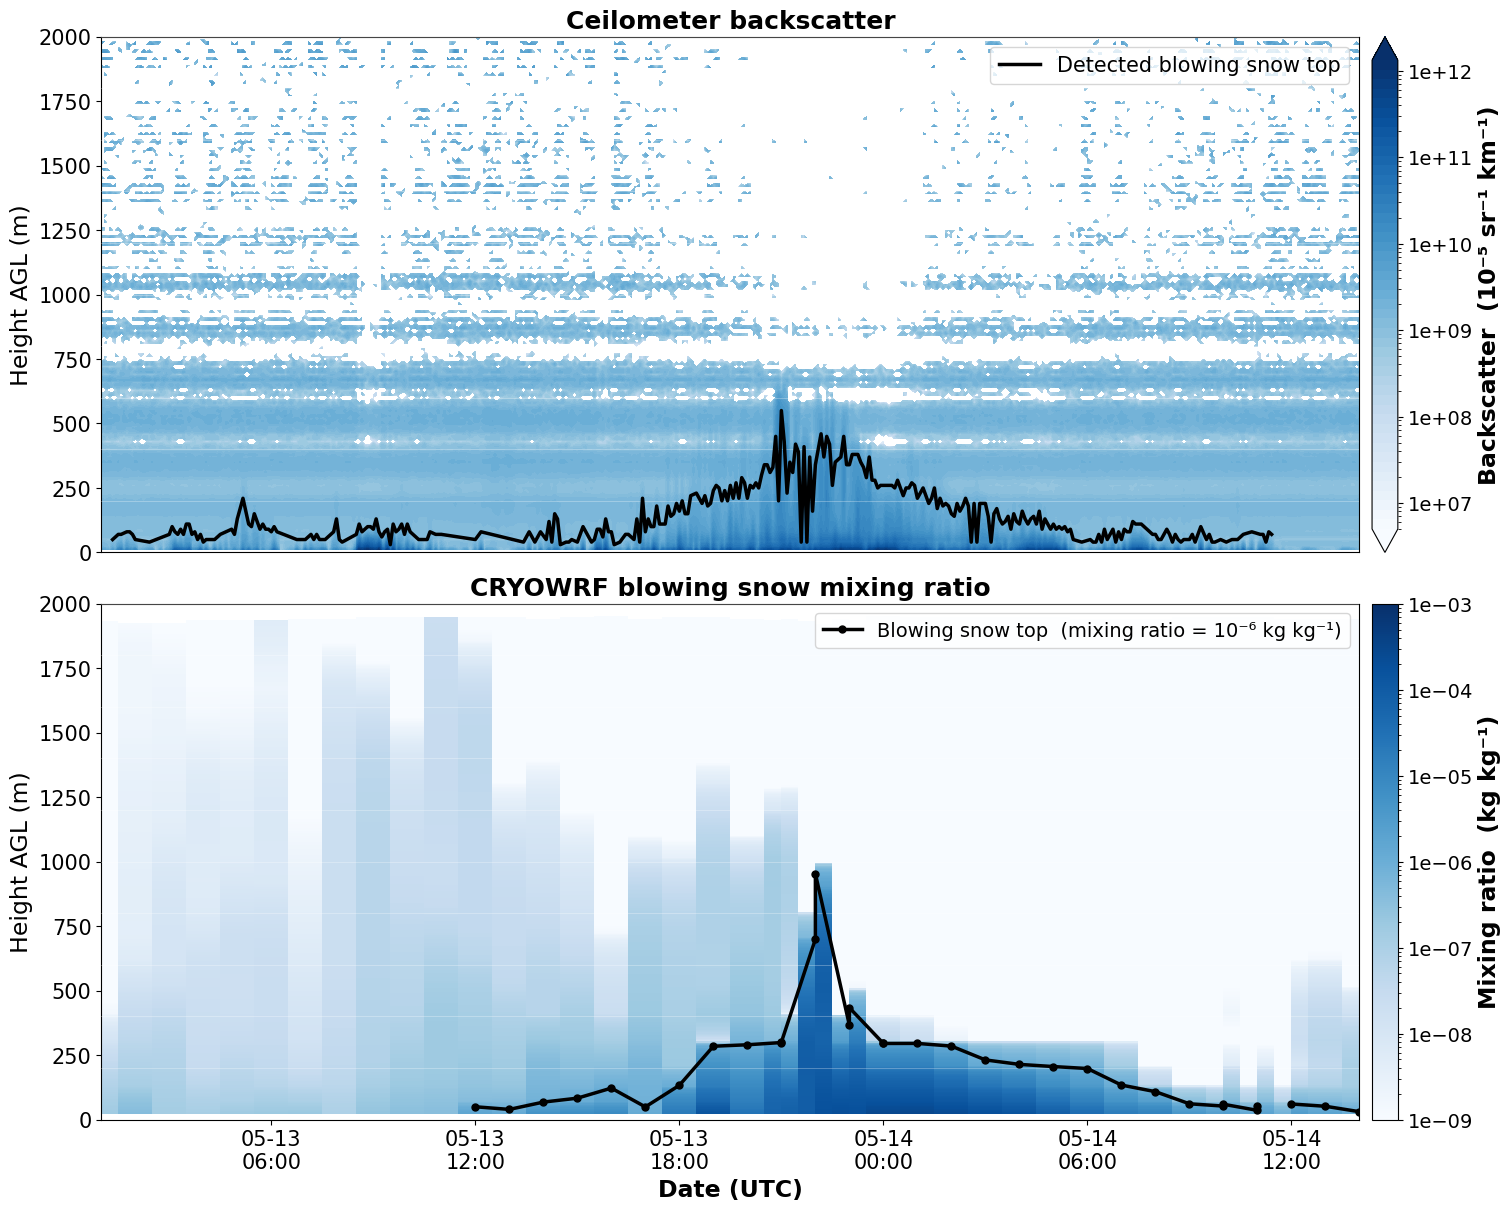

In [15]:
plot_event('cold_kat')

## Transitional synoptic — Apr 2025

  trans_syn: 2/20 timestep con mixing ratio >= 1e-6 kg/kg


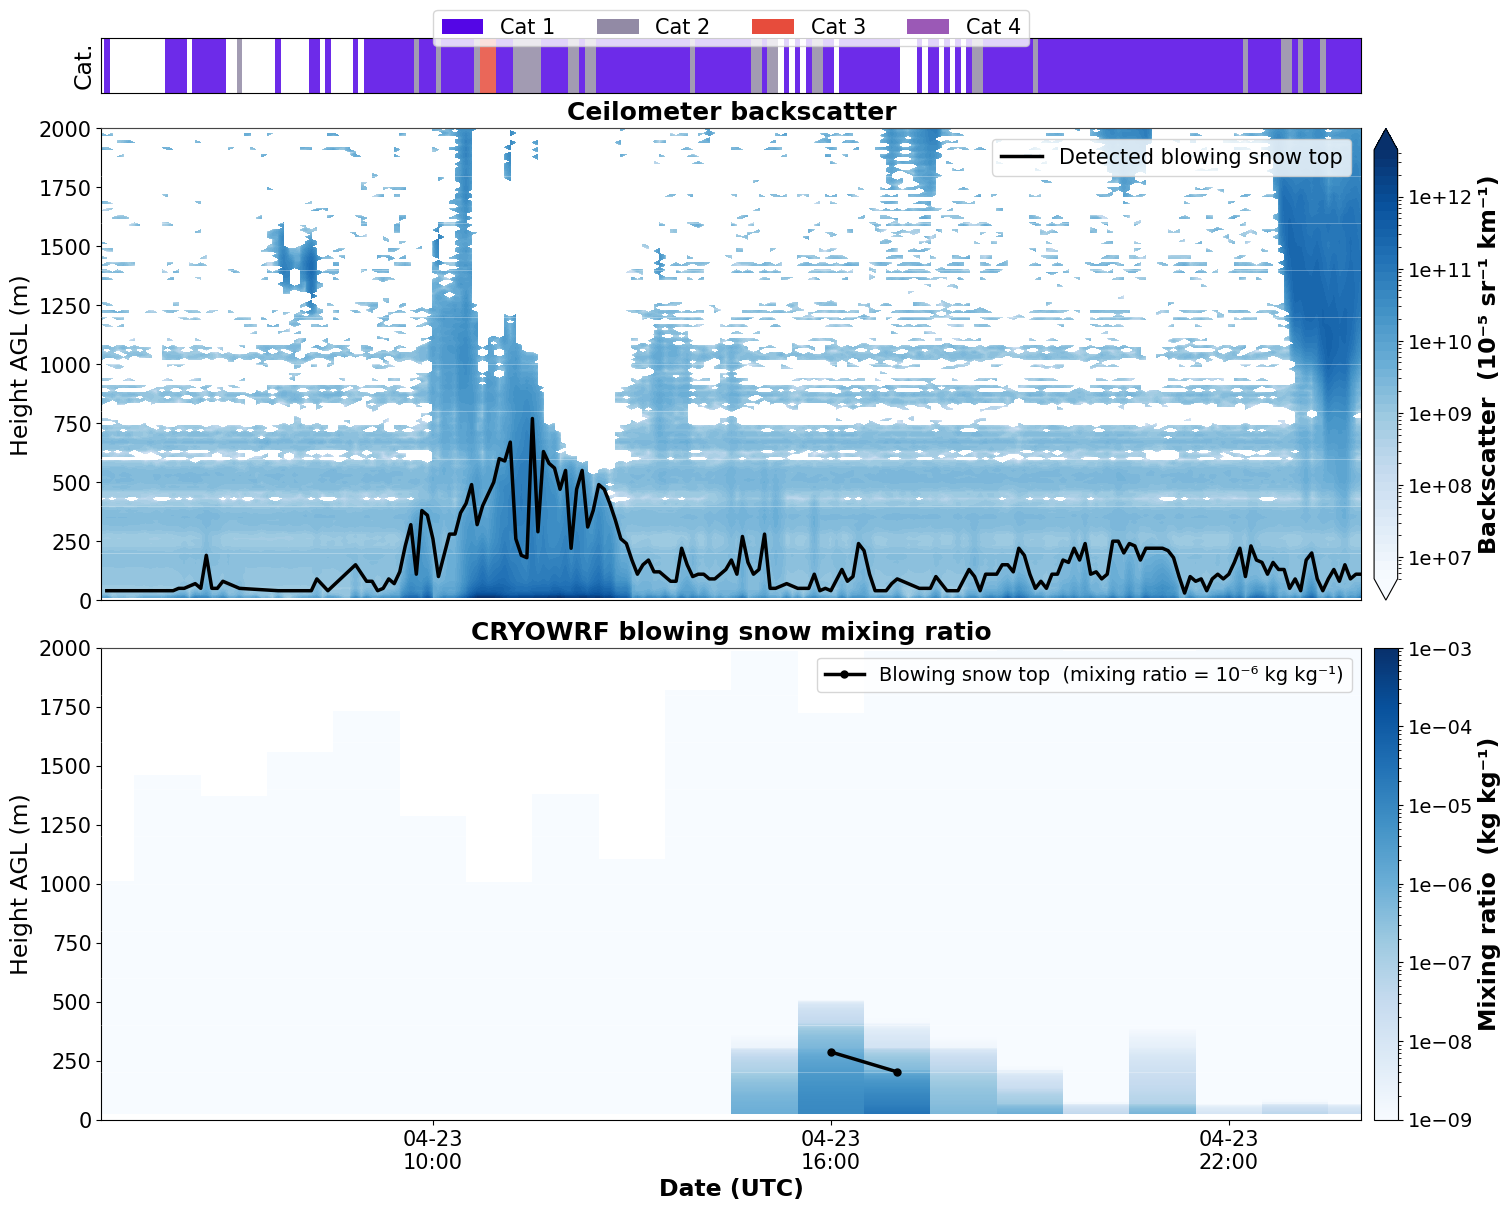

In [ ]:
plot_event('trans_syn')

## Warm synoptic — Apr 2025

  warm_syn: 12/24 timestep con mixing ratio >= 1e-6 kg/kg


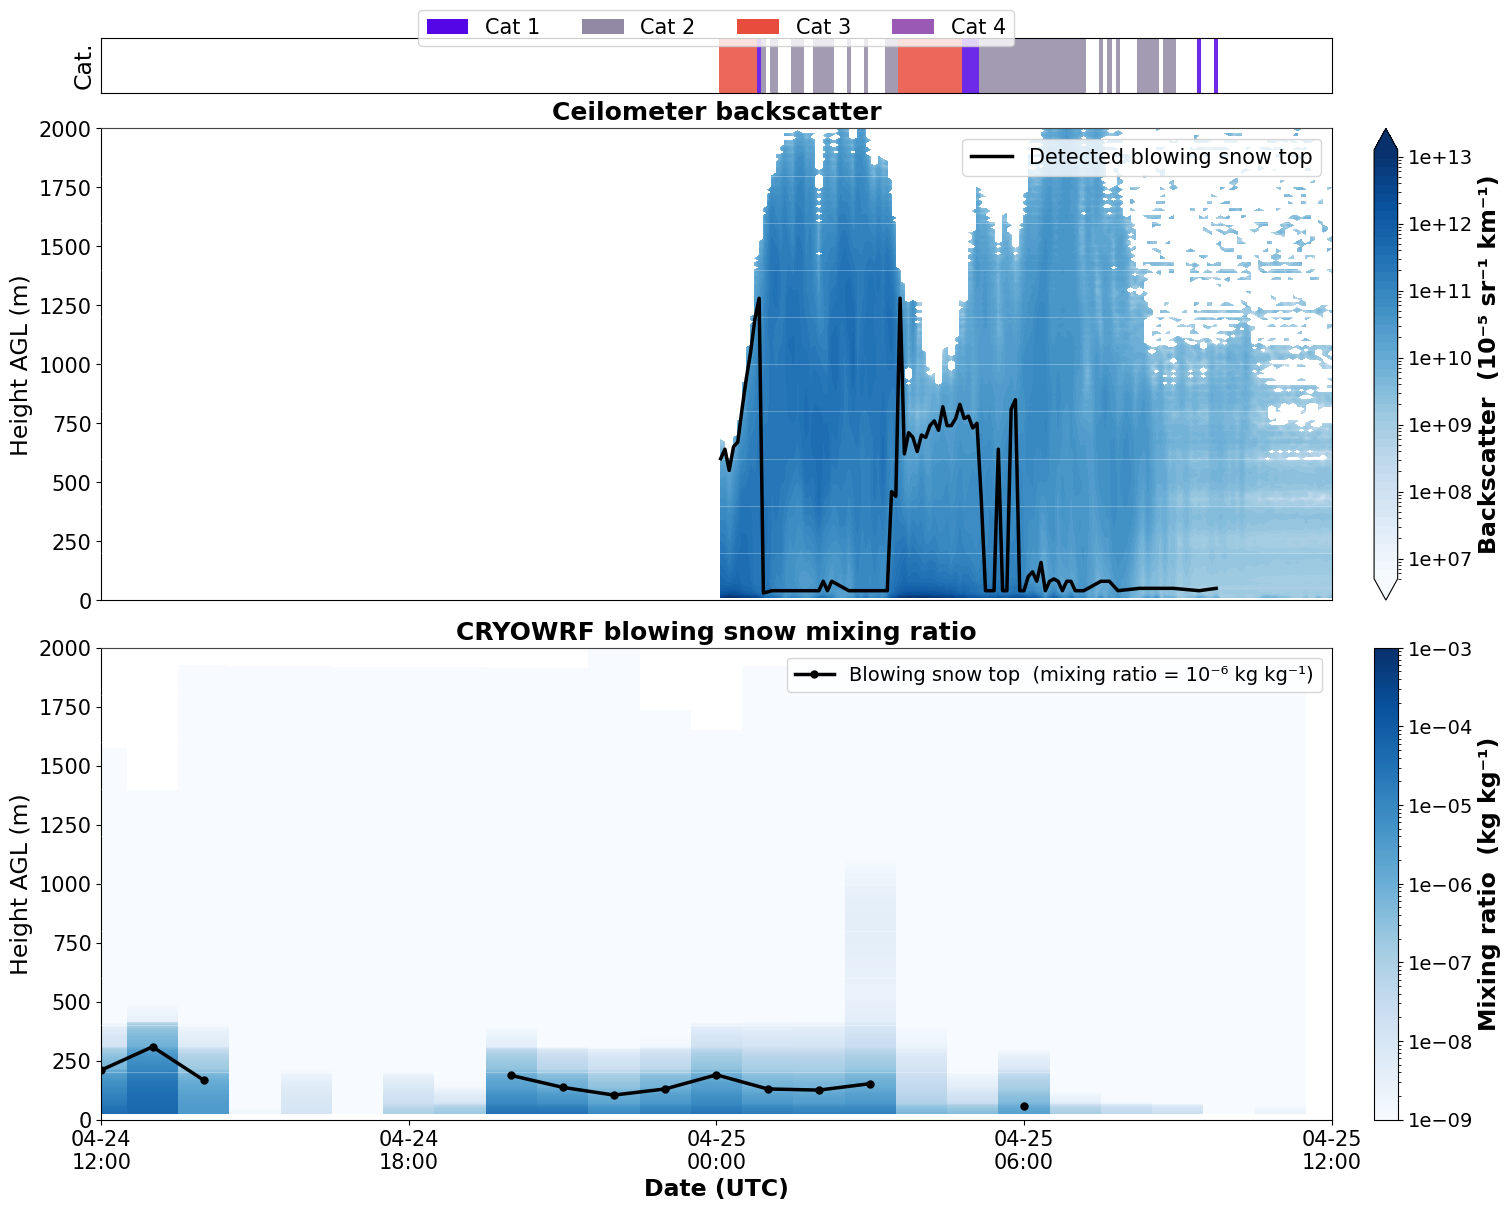

In [ ]:
plot_event('warm_syn')

## Save all figures

In [ ]:
OUT_DIR = r'C:\Users\lory2\Desktop\tesi\wrf_notebooks\figures'
os.makedirs(OUT_DIR, exist_ok=True)

for key in SIMULATIONS:
    for show_line, suffix in [(False, 'noline'), (True, 'line')]:
        ev    = SIMULATIONS[key]
        label = ev['label']
        t_start = ev['start']
        t_end   = ev['end']
        year    = ev['ceil_year']

        cc = ceilo_cache[key]
        bsc_all, times_all, height_arr = cc['bsc'], cc['times'], cc['height']
        if bsc_all is None:
            print(f'No ceilometer data for {key}, skipped.')
            continue

        h_mask   = height_arr <= Z_MAX_AGL
        height_c = height_arr[h_mask]
        mask_c   = (times_all >= t_start) & (times_all <= t_end)
        times_c  = times_all[mask_c]
        bsc_plot = bsc_all[mask_c, :][:, h_mask].T

        t_num_c     = mdates.date2num(times_c)
        t_start_num = mdates.date2num(t_start)
        t_end_num   = mdates.date2num(t_end)
        T_c, H_c   = np.meshgrid(t_num_c, height_c)

        wrf_times, z_common, bsqi_grid = wrf_data[key]
        t_num_w = mdates.date2num(wrf_times)
        if len(t_num_w) > 1:
            dh = np.diff(t_num_w) / 2
            t_edges_w = np.concatenate([[t_num_w[0] - dh[0]],
                                         t_num_w[:-1] + dh,
                                         [t_num_w[-1] + dh[-1]]])
        else:
            t_edges_w = np.array([t_num_w[0] - 1/48, t_num_w[0] + 1/48])
        dz        = z_common[1] - z_common[0]
        z_edges_w = np.append(z_common - dz/2, z_common[-1] + dz/2)
        bsqi_plot = np.where(bsqi_grid > 0, bsqi_grid, np.nan)

        threshold = 1e-6
        iso_heights = []
        for i in range(bsqi_plot.shape[0]):
            col   = bsqi_plot[i, :]
            above = np.isfinite(col) & (col >= threshold)
            if not above.any():
                iso_heights.append(np.nan); continue
            idx = np.where(above)[0][-1]
            if idx == len(z_common) - 1:
                iso_heights.append(z_common[-1])
            else:
                z0, z1 = z_common[idx], z_common[idx + 1]
                v0, v1 = col[idx], col[idx + 1]
                if v1 < threshold and (v0 - v1) != 0:
                    frac = (v0 - threshold) / (v0 - v1)
                    iso_heights.append(z0 + frac * (z1 - z0))
                else:
                    iso_heights.append(z_common[idx])
        iso_heights = np.array(iso_heights)

        df_blsn = blsn_df[year]
        df_cat  = df_blsn[
            (df_blsn['datetime'] >= t_start) & (df_blsn['datetime'] <= t_end) &
            (df_blsn['category'].isin([1, 2, 3, 4]))].copy()
        df_line = df_blsn[
            (df_blsn['datetime'] >= t_start) & (df_blsn['datetime'] <= t_end) &
            (df_blsn['top_of_detected_BLSN'] < 99999999.9)].copy()

        fig = plt.figure(figsize=(14, 11), constrained_layout=True)
        gs  = GridSpec(3, 1, figure=fig, height_ratios=[0.35, 3, 3])
        ax_cat  = fig.add_subplot(gs[0])
        ax_ceil = fig.add_subplot(gs[1])
        ax_wrf  = fig.add_subplot(gs[2])

        for _, row in df_cat.iterrows():
            t_val = mdates.date2num(row['datetime'])
            width = 5 / (24 * 60)
            ax_cat.add_patch(mpatches.Rectangle(
                (t_val - width/2, 0), width, 1,
                facecolor=CAT_COLORS[row['category']], edgecolor='none', alpha=0.85))
        ax_cat.set_xlim(t_start_num, t_end_num); ax_cat.set_ylim(0, 1)
        ax_cat.set_ylabel('Cat.', fontsize=17)
        ax_cat.set_yticks([]); ax_cat.set_xticks([])
        cat_patches = [mpatches.Patch(facecolor=CAT_COLORS[i], label=f'Cat {i}') for i in [1, 2, 3, 4]]
        ax_cat.legend(handles=cat_patches, loc='upper center', ncol=4,
                      bbox_to_anchor=(0.5, 1.7), fontsize=15, frameon=True, fancybox=True)

        bsc_pos    = bsc_plot.copy().astype(float) * 1e8
        bsc_pos[bsc_pos <= 0] = np.nan
        valid_vals = bsc_pos[np.isfinite(bsc_pos)]
        if valid_vals.size > 0:
            bsc_min = np.nanmin(valid_vals); bsc_max = np.nanmax(valid_vals)
            levels  = np.logspace(np.log10(bsc_min), np.log10(bsc_max), 50)
            cax_c   = ax_ceil.contourf(T_c, H_c, bsc_pos,
                                        levels=levels, norm=LogNorm(vmin=bsc_min, vmax=bsc_max),
                                        cmap='Blues', extend='both')
            cbar_c  = plt.colorbar(cax_c, ax=ax_ceil, pad=0.01)
            cbar_c.set_label('Backscatter  (10⁻⁵ sr⁻¹ km⁻¹)', fontsize=17   , fontweight='bold')
            cbar_c.ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
            cbar_c.ax.yaxis.set_major_formatter(LogFormatter(base=10.0, labelOnlyBase=True))
            cbar_c.ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)))
            cbar_c.ax.yaxis.set_minor_formatter(plt.NullFormatter())
            cbar_c.ax.tick_params(labelsize=14)
        _hgrid(ax_ceil)
        if not df_line.empty:
            t_ln = mdates.date2num(df_line['datetime'].values)
            ax_ceil.plot(t_ln, df_line['top_of_detected_BLSN'].values,
                         color='black', linewidth=2.5, label='Detected blowing snow top', zorder=5)
            ax_ceil.legend(loc='upper right', fontsize=15)
        ax_ceil.set_xlim(t_start_num, t_end_num); ax_ceil.set_ylim(0, Z_MAX_AGL)
        ax_ceil.set_ylabel('Height AGL (m)', fontsize=17)
        ax_ceil.set_title(f'Ceilometer backscatter', fontsize=18, fontweight='bold')
        ax_ceil.set_xticks([]); ax_ceil.tick_params(axis='y', labelsize=15)

        pm = ax_wrf.pcolormesh(t_edges_w, z_edges_w, bsqi_plot.T,
                                norm=LogNorm(vmin=BSQI_VMIN, vmax=BSQI_VMAX),
                                cmap='Blues', shading='flat')
        _hgrid(ax_wrf)
        if show_line:
            ax_wrf.plot(t_num_w, iso_heights, color='black', linewidth=2.5,
                        marker='o', markersize=5, zorder=10,
                        label='Blowing snow top  (mixing ratio = 10⁻⁶ kg kg⁻¹)')
            ax_wrf.legend(loc='upper right', fontsize=14)
        cb_w = plt.colorbar(pm, ax=ax_wrf, pad=0.01)
        cb_w.ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
        cb_w.ax.yaxis.set_major_formatter(LogFormatter(base=10.0, labelOnlyBase=True))
        cb_w.ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)))
        cb_w.ax.yaxis.set_minor_formatter(plt.NullFormatter())
        cb_w.ax.tick_params(labelsize=14)
        cb_w.set_label('Mixing ratio  (kg kg⁻¹)', fontsize=17, fontweight='bold')
        ax_wrf.set_xlim(t_start_num, t_end_num); ax_wrf.set_ylim(0, Z_MAX_AGL)
        ax_wrf.set_ylabel('Height AGL (m)', fontsize=17)
        ax_wrf.set_xlabel('Date (UTC)', fontsize=17, fontweight='bold')
        ax_wrf.set_title(f'CRYOWRF blowing snow mixing ratio', fontsize=18, fontweight='bold')
        ax_wrf.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
        ax_wrf.xaxis.set_major_locator(mdates.HourLocator(interval=6))
        ax_wrf.tick_params(axis='both', labelsize=15)
        ax_cat.set_xlim(ax_wrf.get_xlim()); ax_ceil.set_xlim(ax_wrf.get_xlim())
        plt.suptitle(label, fontsize=16)

        fname = os.path.join(OUT_DIR, f'vertical_bs_{key}_{suffix}.png')
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.close()
        print(f'Saved: {fname}')

print('\nAll figures saved.')

Salvato: C:\Users\lory2\Desktop\tesi\wrf_notebooks\figures\vertical_bs_cold_kat_noline.png
Salvato: C:\Users\lory2\Desktop\tesi\wrf_notebooks\figures\vertical_bs_cold_kat_line.png
Salvato: C:\Users\lory2\Desktop\tesi\wrf_notebooks\figures\vertical_bs_trans_syn_noline.png
Salvato: C:\Users\lory2\Desktop\tesi\wrf_notebooks\figures\vertical_bs_trans_syn_line.png
Salvato: C:\Users\lory2\Desktop\tesi\wrf_notebooks\figures\vertical_bs_warm_syn_noline.png
Salvato: C:\Users\lory2\Desktop\tesi\wrf_notebooks\figures\vertical_bs_warm_syn_line.png

Tutti i file salvati.


## Backscatter minus clear-sky profile

Profilo cielo sereno: 770 bin, min=9.0  max=3921.1  [raw units]
  cold_kat: anomaly range [-57050000000.0, 1318150000000.0]  (10⁻⁵ sr⁻¹ km⁻¹)


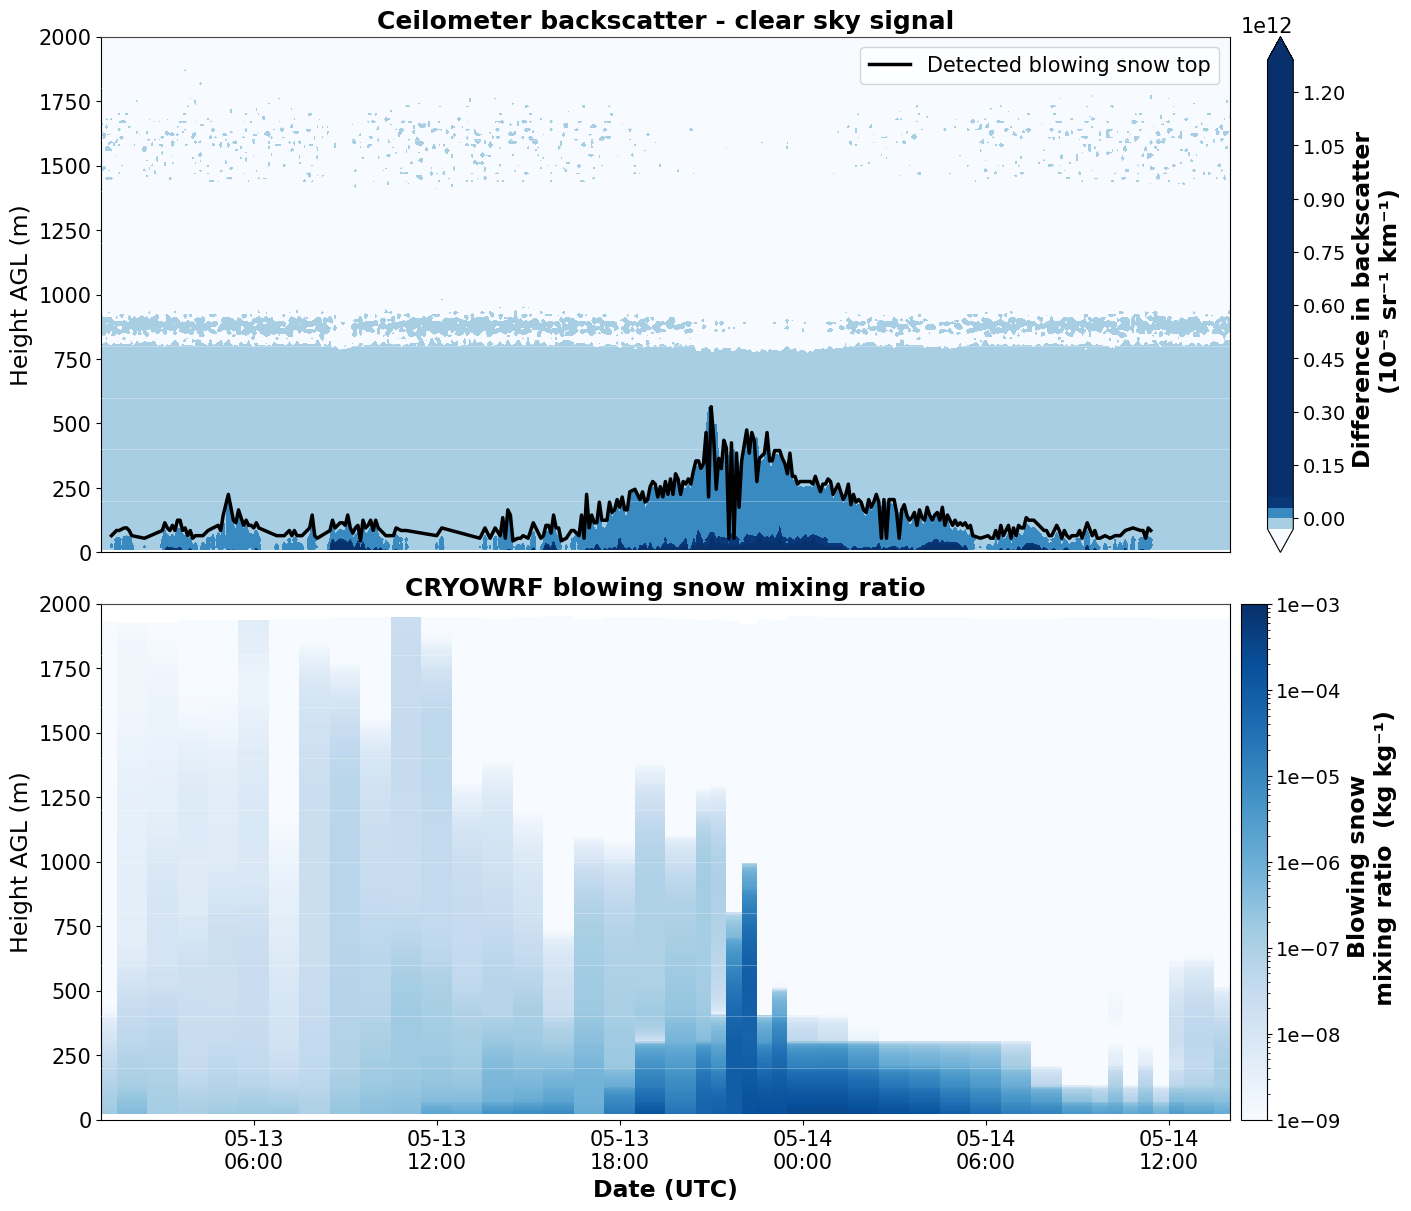

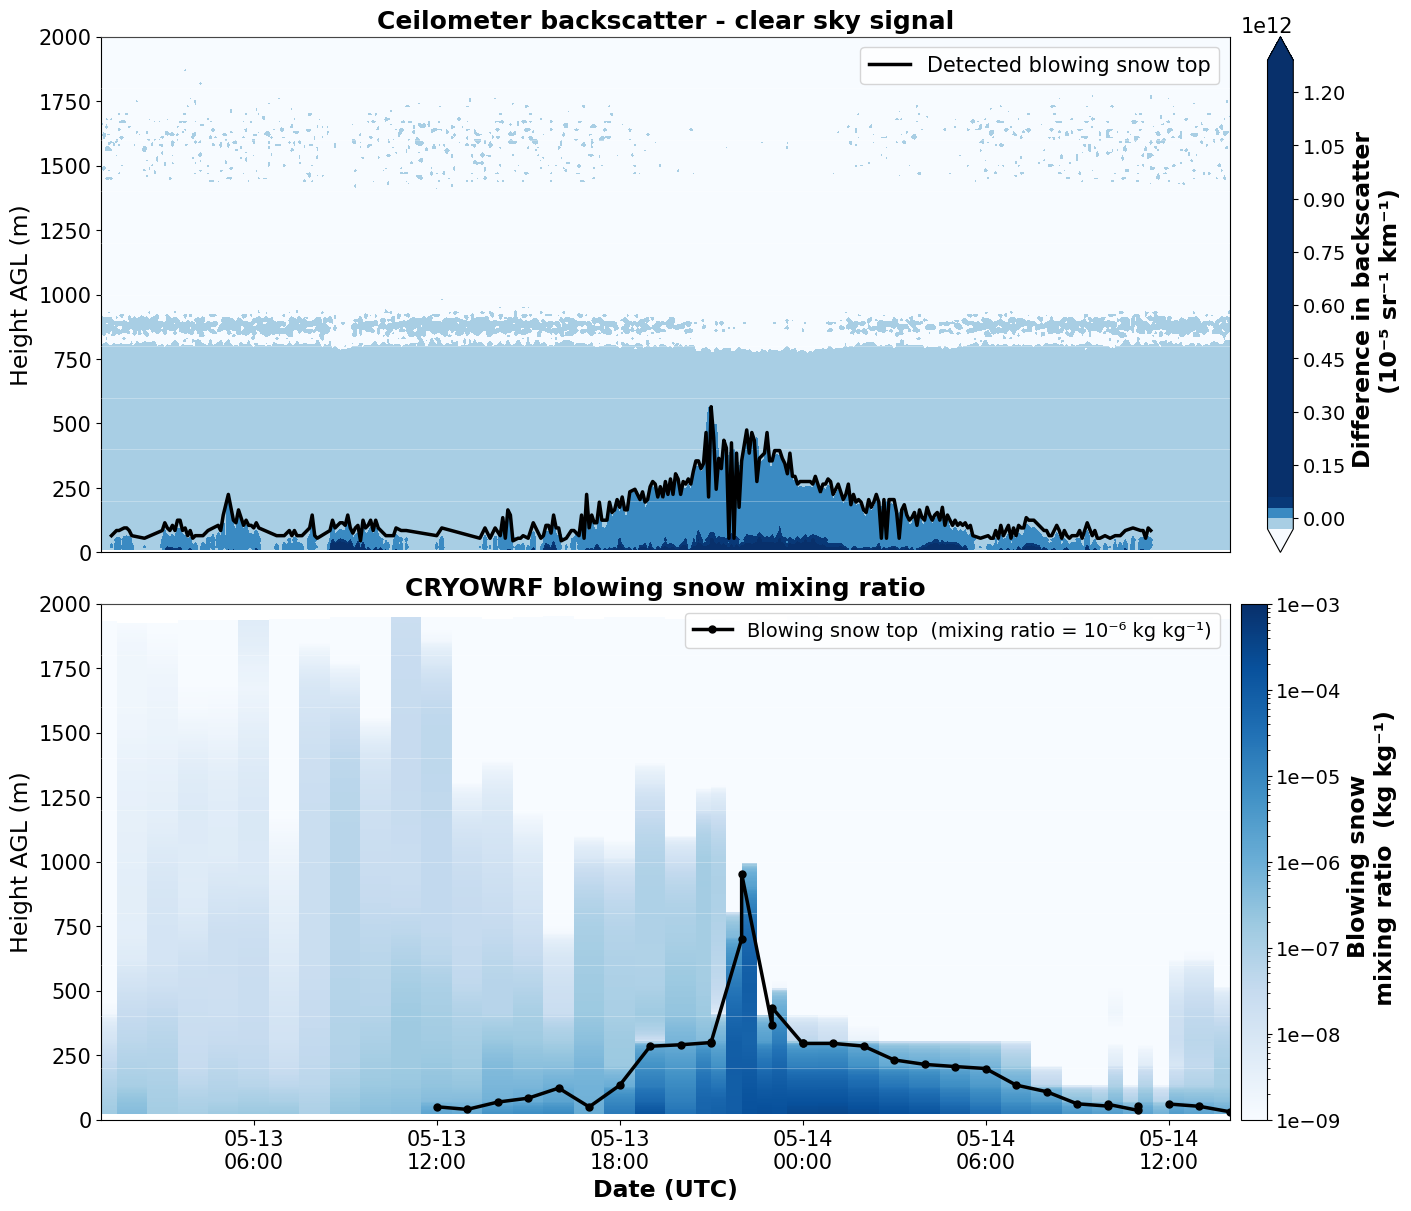

  trans_syn: anomaly range [-79105000000.0, 4429750000000.0]  (10⁻⁵ sr⁻¹ km⁻¹)


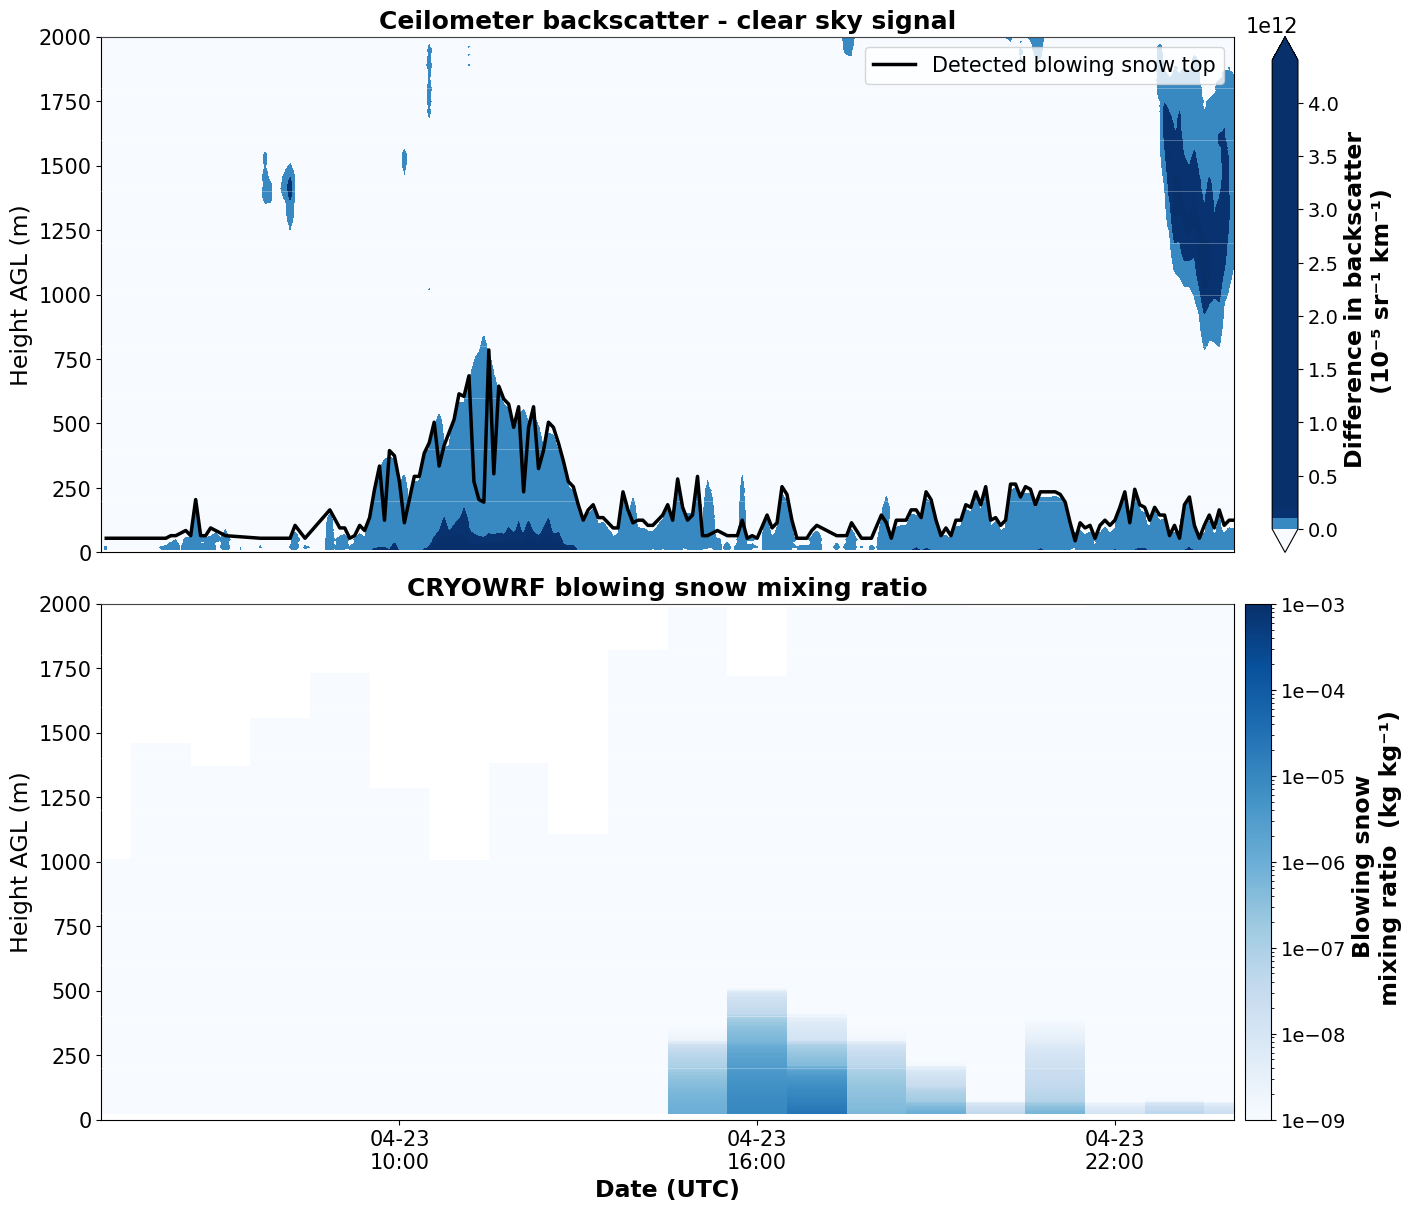

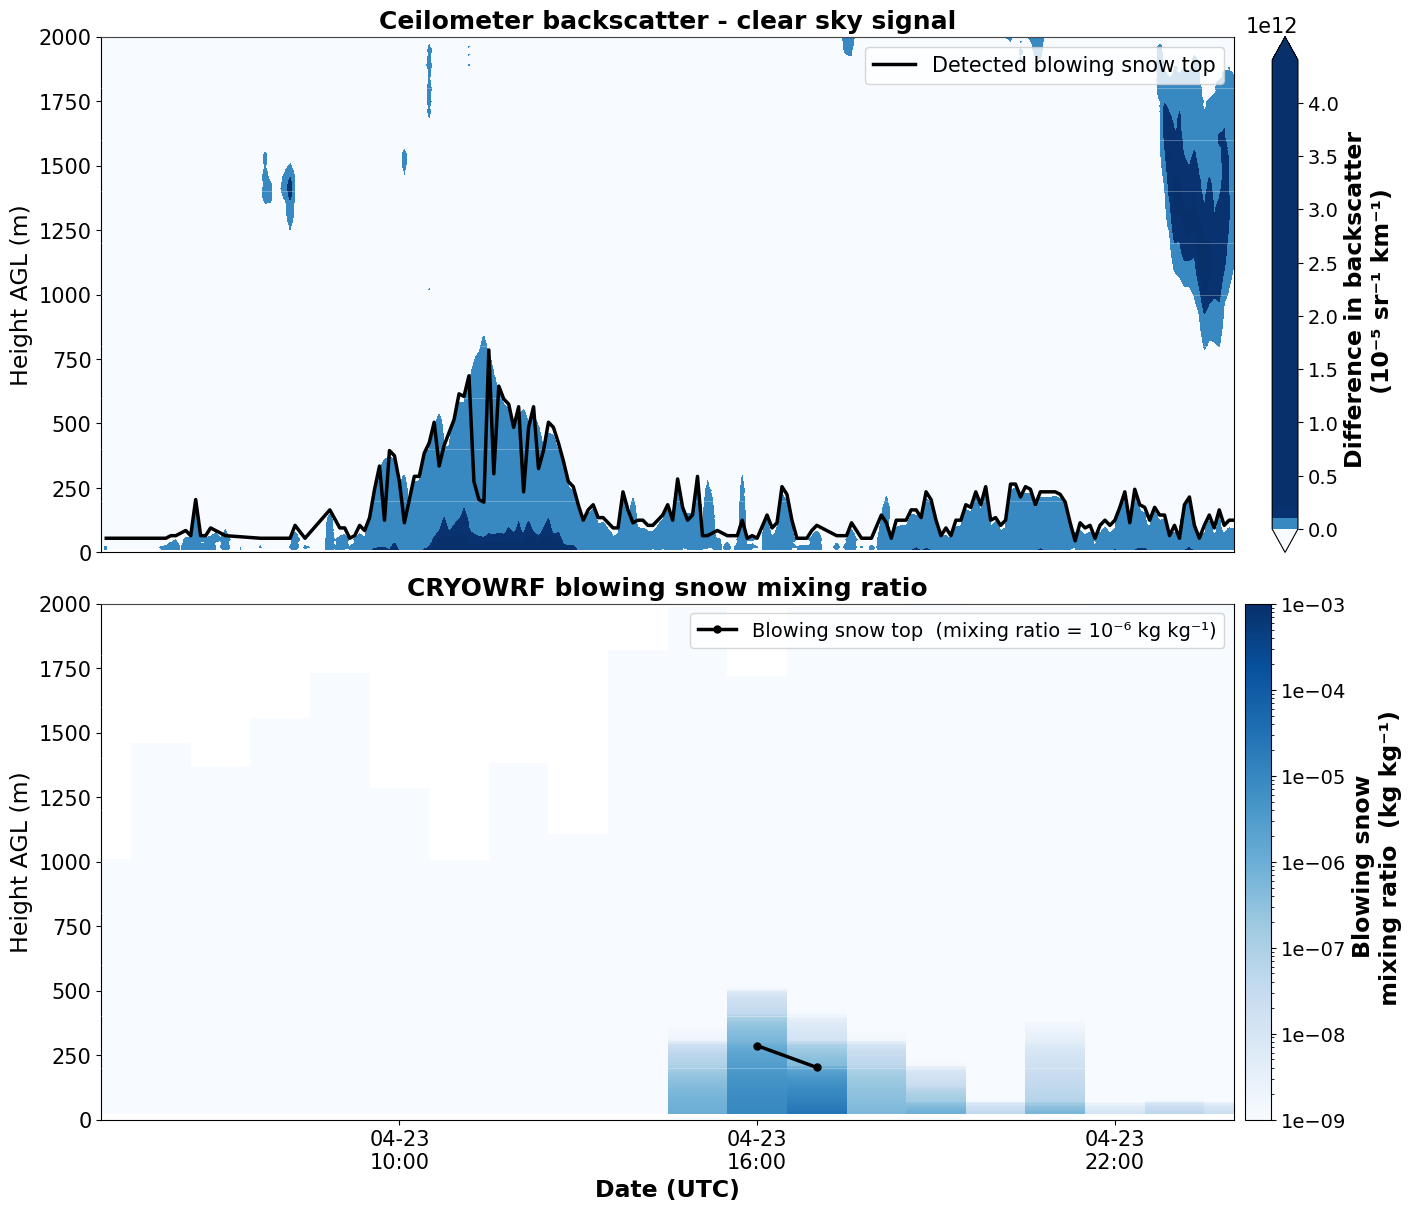

  warm_syn: anomaly range [-138295000000.0, 12564210000000.0]  (10⁻⁵ sr⁻¹ km⁻¹)


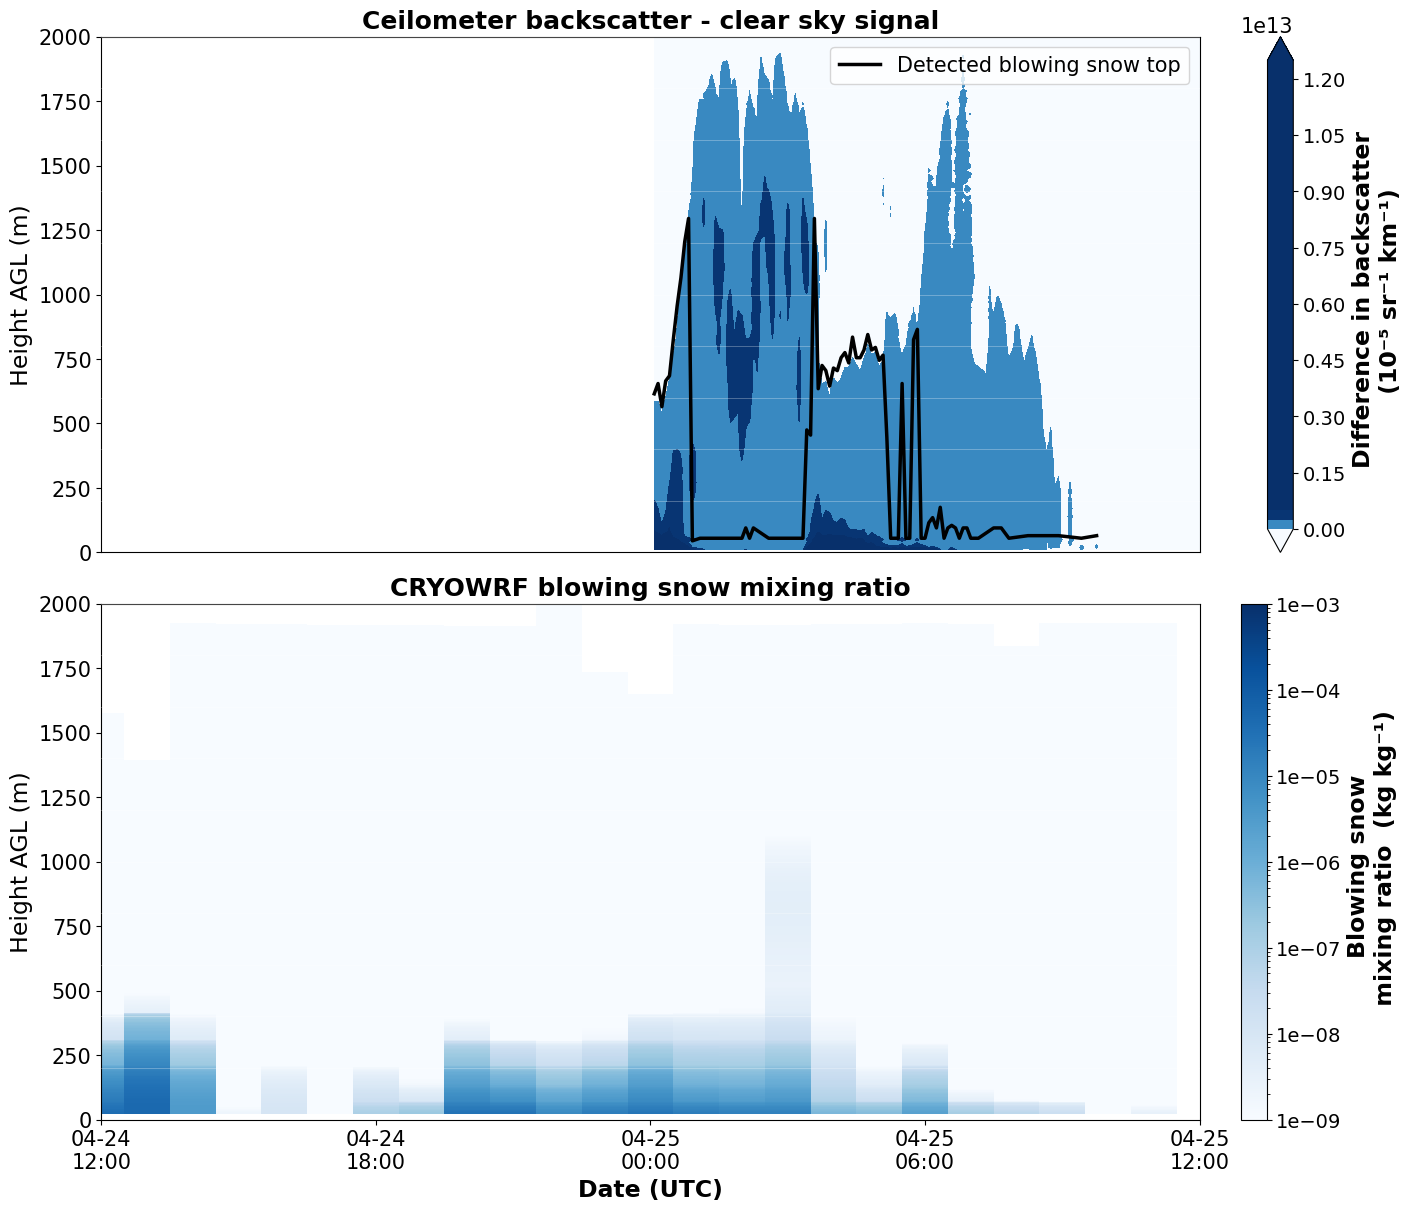

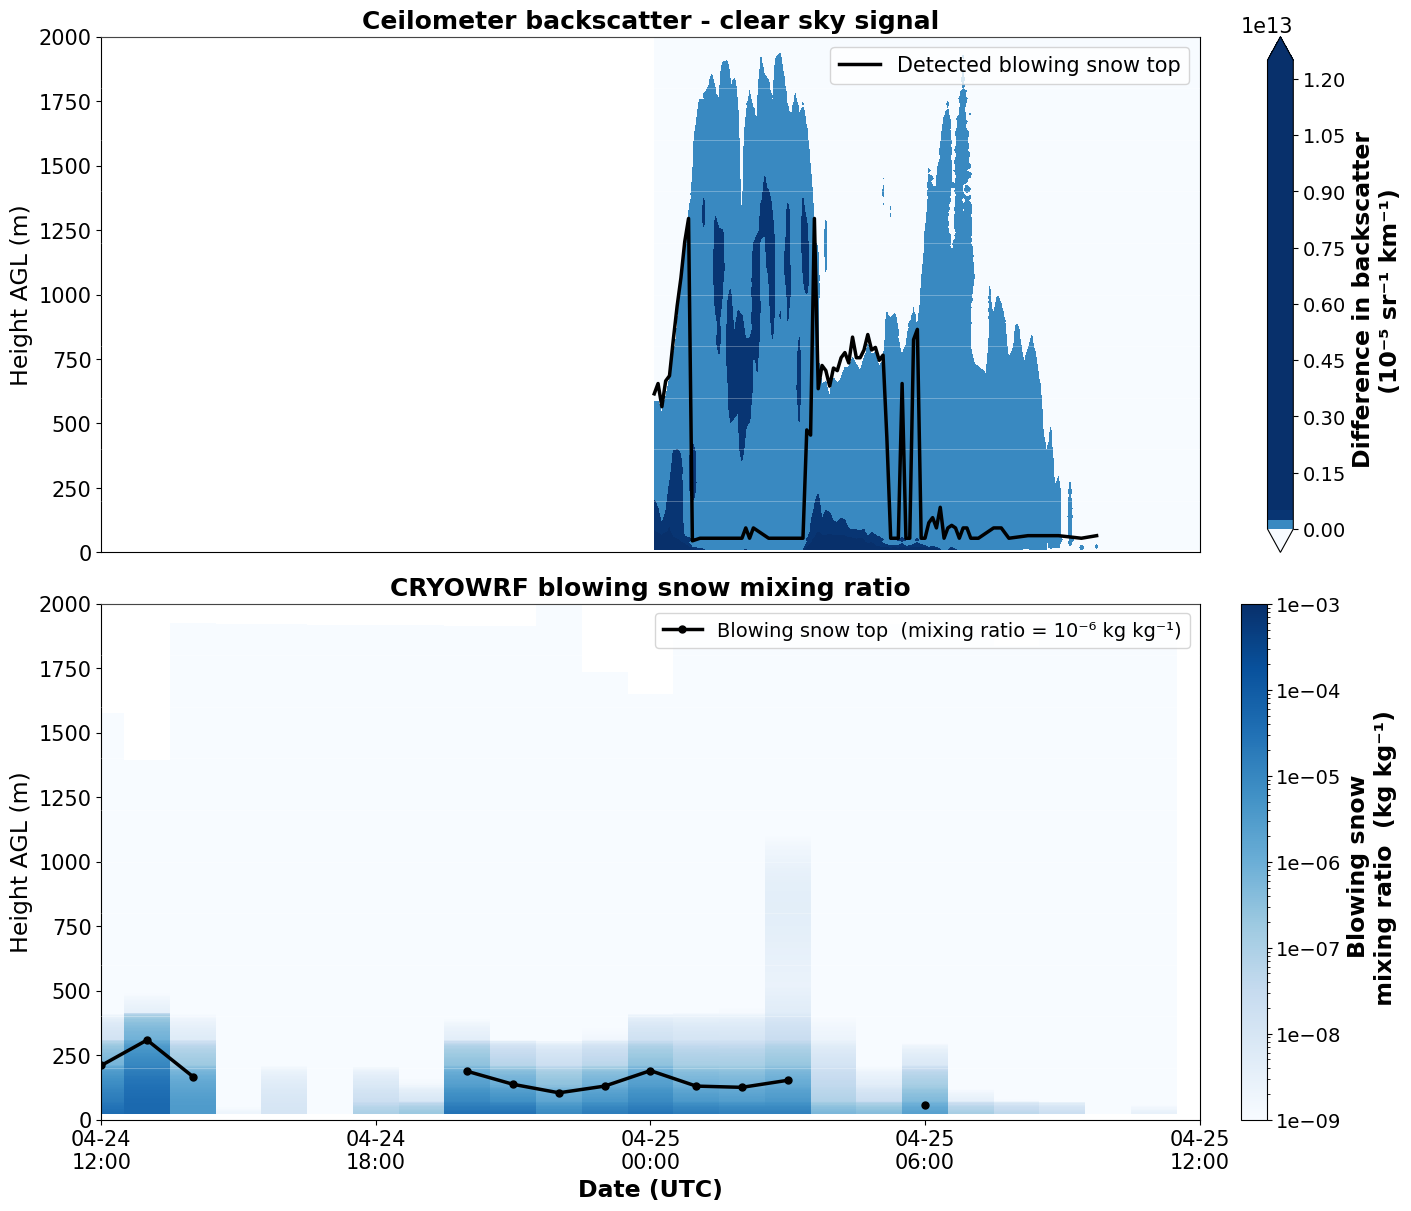

In [19]:
# ── Load clear-sky profile ───────────────────────────────────────────────
_cs_raw  = open(r'C:\Users\lory2\Desktop\tesi\BLSN\good_notebooks\clear_sky_profile_bin1_21.csv').read()
_cs_vals = _cs_raw.strip().split('\n')[0]
if '\t' in _cs_vals:
    _cs_vals = _cs_vals.split('\t', 1)[1]
CLEAR_SKY_PROFILE = np.array([float(v) for v in _cs_vals.split(',')])

print(f'Clear-sky profile: {len(CLEAR_SKY_PROFILE)} bins, '
      f'min={CLEAR_SKY_PROFILE.min():.1f}  max={CLEAR_SKY_PROFILE.max():.1f}  [raw units]')

# ── Save options ───────────────────────────────────────────────────────
SAVE_ANOM    = False   # True to save
OUT_DIR_ANOM = r'C:\Users\lory2\Desktop\tesi\wrf_notebooks\figures'

from matplotlib.colors import TwoSlopeNorm

for key in SIMULATIONS:
    ev      = SIMULATIONS[key]
    label   = ev['label']
    t_start = ev['start']
    t_end   = ev['end']
    year    = ev['ceil_year']

    cc = ceilo_cache[key]
    bsc_all, times_all, height_arr = cc['bsc'], cc['times'], cc['height']
    if bsc_all is None:
        print(f'No ceilometer data for {key}, skipped.')
        continue

    h_mask   = height_arr <= Z_MAX_AGL
    height_c = height_arr[h_mask]
    mask_c   = (times_all >= t_start) & (times_all <= t_end)
    times_c  = times_all[mask_c]
    bsc_plot = bsc_all[mask_c, :][:, h_mask].T   # (height, time), raw units

    # clear-sky profile on the same gates (same raw units as bsc_plot)
    cs_interp = np.interp(height_c, height_arr, CLEAR_SKY_PROFILE,
                           left=CLEAR_SKY_PROFILE[0],
                           right=CLEAR_SKY_PROFILE[-1])   # (n_height_c,)

    # subtract in raw units, then convert to 10⁻⁵ sr⁻¹ km⁻¹
    anomaly = (bsc_plot.astype(float) - cs_interp[:, np.newaxis]) * 1e8

    print(f'  {key}: anomaly range [{np.nanmin(anomaly):.1f}, {np.nanmax(anomaly):.1f}]  (10⁻⁵ sr⁻¹ km⁻¹)')

    t_num_c     = mdates.date2num(times_c)
    t_start_num = mdates.date2num(t_start)
    t_end_num   = mdates.date2num(t_end)
    T_c, H_c   = np.meshgrid(t_num_c, height_c)

    wrf_times, z_common, bsqi_grid = wrf_data[key]
    t_num_w = mdates.date2num(wrf_times)
    if len(t_num_w) > 1:
        dh = np.diff(t_num_w) / 2
        t_edges_w = np.concatenate([[t_num_w[0] - dh[0]],
                                     t_num_w[:-1] + dh,
                                     [t_num_w[-1] + dh[-1]]])
    else:
        t_edges_w = np.array([t_num_w[0] - 1/48, t_num_w[0] + 1/48])
    dz        = z_common[1] - z_common[0]
    z_edges_w = np.append(z_common - dz/2, z_common[-1] + dz/2)
    bsqi_plot = np.where(bsqi_grid > 0, bsqi_grid, np.nan)

    threshold   = 1e-6
    iso_heights = []
    for i in range(bsqi_plot.shape[0]):
        col   = bsqi_plot[i, :]
        above = np.isfinite(col) & (col >= threshold)
        if not above.any():
            iso_heights.append(np.nan); continue
        idx = np.where(above)[0][-1]
        if idx == len(z_common) - 1:
            iso_heights.append(z_common[-1])
        else:
            z0, z1 = z_common[idx], z_common[idx + 1]
            v0, v1 = col[idx], col[idx + 1]
            if v1 < threshold and (v0 - v1) != 0:
                frac = (v0 - threshold) / (v0 - v1)
                iso_heights.append(z0 + frac * (z1 - z0))
            else:
                iso_heights.append(z_common[idx])
    iso_heights = np.array(iso_heights)

    df_blsn = blsn_df[year]
    df_cat  = df_blsn[
       (df_blsn['datetime'] >= t_start) & (df_blsn['datetime'] <= t_end) &
        (df_blsn['category'].isin([1, 2, 3, 4]))].copy()
    df_line = df_blsn[
        (df_blsn['datetime'] >= t_start) & (df_blsn['datetime'] <= t_end) &
        (df_blsn['top_of_detected_BLSN'] < 99999999.9)].copy()

    anom_abs  = np.nanpercentile(np.abs(anomaly), 99)
    norm_anom = TwoSlopeNorm(vmin=-anom_abs, vcenter=0, vmax=anom_abs)

    for show_line, suffix in [(False, 'noline'), (True, 'line')]:
        fig = plt.figure(figsize=(14, 12), constrained_layout=True)
        gs  = GridSpec(2, 1, figure=fig, height_ratios=[3, 3])
        ax_ceil = fig.add_subplot(gs[0])
        ax_wrf  = fig.add_subplot(gs[1])

        for _, row in df_cat.iterrows():
            t_val = mdates.date2num(row['datetime'])
            width = 5 / (24 * 60)

        cax_a  = ax_ceil.contourf(T_c, H_c, anomaly,
                                   levels=50, norm=norm_anom,
                                   cmap='Blues', extend='both')
        cbar_a = plt.colorbar(cax_a, ax=ax_ceil, pad=0.01)
        cbar_a.set_label('Difference in backscatter \n (10⁻⁵ sr⁻¹ km⁻¹)', fontsize=17, fontweight='bold')
        cbar_a.ax.tick_params(labelsize=14)
        _hgrid(ax_ceil)
        if not df_line.empty:
            t_ln = mdates.date2num(df_line['datetime'].values)
            ax_ceil.plot(t_ln, df_line['top_of_detected_BLSN'].values+15,
                         color='black', linewidth=2.5,
                         label='Detected blowing snow top', zorder=5)
            ax_ceil.legend(loc='upper right', fontsize=15)
        ax_ceil.set_xlim(t_start_num, t_end_num); ax_ceil.set_ylim(0, Z_MAX_AGL)
        ax_ceil.set_ylabel('Height AGL (m)', fontsize=17)
        ax_ceil.set_title(f'Ceilometer backscatter - clear sky signal',
                          fontsize=18, fontweight='bold')
        ax_ceil.set_xticks([]); ax_ceil.tick_params(axis='y', labelsize=15)

        pm = ax_wrf.pcolormesh(t_edges_w, z_edges_w, bsqi_plot.T,
                                norm=LogNorm(vmin=BSQI_VMIN, vmax=BSQI_VMAX),
                                cmap='Blues', shading='flat')
        _hgrid(ax_wrf)
        if show_line:
            ax_wrf.plot(t_num_w, iso_heights, color='black', linewidth=2.5,
                        marker='o', markersize=5, zorder=10,
                        label='Blowing snow top  (mixing ratio = 10⁻⁶ kg kg⁻¹)')
            ax_wrf.legend(loc='upper right', fontsize=14)
        cb_w = plt.colorbar(pm, ax=ax_wrf, pad=0.01)
        cb_w.ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=15))
        cb_w.ax.yaxis.set_major_formatter(LogFormatter(base=10.0, labelOnlyBase=True))
        cb_w.ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)))
        cb_w.ax.yaxis.set_minor_formatter(plt.NullFormatter())
        cb_w.ax.tick_params(labelsize=14)
        cb_w.set_label('Blowing snow \n mixing ratio  (kg kg⁻¹)', fontsize=17, fontweight='bold')
        ax_wrf.set_xlim(t_start_num, t_end_num); ax_wrf.set_ylim(0, Z_MAX_AGL)
        ax_wrf.set_ylabel('Height AGL (m)', fontsize=17)
        ax_wrf.set_xlabel('Date (UTC)', fontsize=17, fontweight='bold')
        ax_wrf.set_title(f'CRYOWRF blowing snow mixing ratio',
                         fontsize=18, fontweight='bold')
        ax_wrf.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d\n%H:%M'))
        ax_wrf.xaxis.set_major_locator(mdates.HourLocator(interval=6))
        ax_wrf.tick_params(axis='both', labelsize=15)

        if SAVE_ANOM:
            os.makedirs(OUT_DIR_ANOM, exist_ok=True)
            fname = os.path.join(OUT_DIR_ANOM, f'vertical_bs_anom_{key}_{suffix}.png')
            plt.savefig(fname, dpi=150, bbox_inches='tight')
            plt.close()
            print(f'Saved: {fname}')
        else:
            plt.show()